In [1]:
# importing all the necessary libraries for our project

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torch.utils.data import DataLoader
import torchvision.transforms as transform

from torchvision.datasets import MNIST
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
import numpy as np

In [2]:
if torch.backends.mps.is_available():
    device=torch.device("mps")
elif torch.cuda.is_available():
    device=torch.device("cuda")
else:
    device=torch.device("cpu")

print("device is: ",device)

# setting the device to as mps.This is the standard code used

device is:  mps


In [3]:
# we want to apply certain standard transformations to our MNIST dataset
# set the MNIST dataset to pytorch Tensors and also scale the values between [0-1]
# the next step involves Normalization the values in the matrix of each MNIST dataset image using standard mean and standard deviation values

transform=transform.Compose([
    transform.ToTensor(), # this transforms our MNIST dataset into pytorch datastructures tensors and also scales them between [0-1]
    transform.Normalize( 
        mean=[0.1307],
        std=[0.3081])   # Normalize our each digit image matrix which represents grayscale images between [0-1] using the standard set of mean and standard values
])

In [4]:
# NEXT STEP----> LOAD THE MNIST DATASET (train and test data)

# (A) The dataset is also present within the torchvision module and can either be imported from there as well
# (B) Or we have created the folder as well containing the dataset from kaggle

In [5]:
train_dataset=MNIST(root="./data",download=True,train=True,transform=transform)
test_dataset=MNIST(root="./data",download=True,train=False,transform=transform)

In [6]:
train_dataset

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=[0.1307], std=[0.3081])
           )

In [7]:
test_dataset

Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=[0.1307], std=[0.3081])
           )

In [8]:
# we use the DataLoader class to load the data in batches and shuffle the training set to remove any bias 

trainloader=DataLoader(train_dataset,batch_size=64,shuffle=True) # the dataset is shuffled and we have set the batch_size as 64 for optimal convergence of our CNN neural network
testloader=DataLoader(test_dataset,batch_size=64,shuffle=False)


In [9]:
trainloader

In [10]:
testloader

In [11]:
# BUILDING OUR CNN MODEL
# WE WILL USE THE OBJECT ORIENTED PROGRAMMING APPROACH TO BUILD OUR CNN MODEL

class CNN(nn.Module): # here we have called the base class nn.Module

    def __init__(self): 
        super(CNN,self).__init__()

        # (stacking the convolutional + MaxPool layer)
        self.conv_layers=nn.Sequential(

            # 1st conv2d + maxpool2d layer 
            nn.Conv2d(in_channels=1,out_channels=32,kernel_size=3,padding=1,stride=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,padding=0,stride=2),


            # 2nd conv2d + maxpool2d layer
            nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,padding=1,stride=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2,padding=0)
        )

        # the MaxPool2d layer reduces the size of the input matrix by half with each pass
        # input to first conv2d layer =(28,28,1) and output after 1st conv2d and MaxPool2d layer =(14,14,32)
        # input to first conv2d layer =(14,14,32) and output after 1st conv2d and MaxPool2d layer =(7,7,64)
        # the final output gives us the matrix with dimensions =(7,7,64)

        # (fullyconnected_layer represents the ANN with 2 hidden layers and ReLU activation function
        self.fullyconnected_layers=nn.Sequential(
            # 1st hidden layer
            nn.Linear(in_features=7*7*64,out_features=256), # the input features to the fullyconnected_layer first have to be flattened to a column matrix type dimension
            nn.ReLU(), # applying the ReLU activation function
            nn.Dropout(p=0.2),

            # 2nd hidden layer
            nn.Linear(in_features=256,out_features=64),
            nn.ReLU(),
            nn.Dropout(p=0.3), # this is added so that 30 percent of the neurons are made inactive during computation and ensure that each neuron learns optimally

            # final output layer
            nn.Linear(in_features=64,out_features=1) # since it is a regression problem and not a classification problem the out_features will be 1 and not 10
        )

    # definig our forward pass
    def forward(self,x):
        x=self.conv_layers(x)
        x=x.view(x.size(0),-1) # to flatten our output matrix before being fed into the fullyconnected_layer
        x=self.fullyconnected_layers(x)
        return x

In [12]:
# create an object of our CNN class,specifing the loss function and our optimizer

model=CNN().to(device)

criterion=nn.MSELoss() # since we have a regression problem the loss function we have used here is MSELoss()
optimizer=optim.Adam(model.parameters(),lr=0.001,weight_decay=1e-4) # we use the Adam optimizer 

In [13]:
# TRAIN OUR CNN MODEL
training_losses=[]
epochs=5 # we want to run 15 epochs to efficiently train our CNN model
validation_losses=[]

for epoch in range(epochs):
    model.train() # set the model to training mode
    running_training_loss=0.0 # accumulate the loss for each iteration within an epoch

    for images,labels in trainloader:
        optimizer.zero_grad() # we do not want the weights to accumulate so we set optimizer.zero_grad()
        images=images.to(device) # set the images to the device ("mps")
        labels=labels.float().unsqueeze(1).to(device) # typecast labels to continuous float values for regression 

        outputs=model.forward(images) # forward-propagation
        loss=criterion(outputs,labels) # loss function computes the loss based on the predicted output and the real output
        loss.backward() # back-propagation step
        optimizer.step() # update our weights and biases of the neural network

        running_training_loss+=loss.item() # add the loss 

    epoch_training_loss=running_training_loss/len(trainloader)  # the training loss for each epoch
    training_losses.append(epoch_training_loss)

    model.eval()
    val_loss=0

    with torch.no_grad():
        for images,labels in testloader:
    
            images=images.to(device)
            labels=labels.float().unsqueeze(1).to(device)
    
            outputs=model(images)
    
            loss=criterion(outputs,labels)
    
            val_loss+=loss.item()


    epoch_val_loss=val_loss/len(testloader)
    validation_losses.append(epoch_val_loss)

    print(f"Epoch {epoch+1}/{epochs} ── Train Loss: {epoch_training_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")


Epoch 1/5 ── Train Loss: 1.7886 | Val Loss: 0.6250
Epoch 2/5 ── Train Loss: 1.0600 | Val Loss: 0.4581
Epoch 3/5 ── Train Loss: 0.8993 | Val Loss: 0.3501
Epoch 4/5 ── Train Loss: 0.7873 | Val Loss: 0.3357
Epoch 5/5 ── Train Loss: 0.7075 | Val Loss: 0.3142


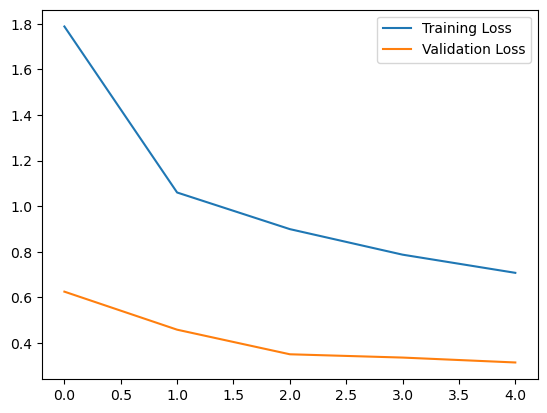

In [14]:
# PLOT THE TRAINING AND THE VALIDATION LOSSES

import matplotlib.pyplot as plt

plt.plot(training_losses,label="Training Loss")
plt.plot(validation_losses,label="Validation Loss")
plt.legend()
plt.show()

In [15]:
# EVALUATIONG OUR MODEL

model.eval() # set our model to evaluation mode
model_predictions=[] # create a 1d array containg the predictions made by the model
model_true_labels=[] # store the true digit labels (0-9) of the MNIST dataset

with torch.no_grad(): 
    for images,labels in testloader: # extract the images and labels in the testloader
        images=images.to(device) # set the images to the mpu device
        outputs=model(images) # compute the real value output(regression problem)

        model_predictions.extend(outputs.to("cpu").numpy().flatten()) # make predictions 
        model_true_labels.extend(labels.numpy())

model_predictions=np.array(model_predictions) 
model_true_labels=np.array(model_true_labels)


mean_squared_error_loss=mean_squared_error(model_true_labels,model_predictions) # compute the mea_squared_error
mean_absolute_error_loss=mean_absolute_error(model_true_labels,model_predictions) # compute the mean_absolute_error
root_mean_squared_error_loss=np.sqrt(mean_squared_error_loss)
r2=r2_score(model_true_labels,model_predictions)

print(f"MEAN SQUARED ERROR (MSE): {mean_squared_error_loss}")
print(f"MEAN ABSOLUTE ERROR (MAE): {mean_absolute_error_loss}")
print(f"ROOT MEAN SQUARED ERROR (RMSE): {root_mean_squared_error_loss}")
print(f"R2 Score: {r2}")

MEAN SQUARED ERROR (MSE): 0.31535279750823975
MEAN ABSOLUTE ERROR (MAE): 0.3446296453475952
ROOT MEAN SQUARED ERROR (RMSE): 0.5615628170634517
R2 Score: 0.96239173412323


In [16]:
iterations=50

# PRINT THE SAMPLE 15 PREDICTED CONTINUOUS VALUES ALONG WITH THE TRUE DIGITS

for iteration in range(iterations):
    print(f"TRUE DIGIT => {model_true_labels[iteration]} AND PREDICTED CONTINUOUS DIGIT => {model_predictions[iteration]}")

TRUE DIGIT => 7 AND PREDICTED CONTINUOUS DIGIT => 6.703024387359619
TRUE DIGIT => 2 AND PREDICTED CONTINUOUS DIGIT => 1.8897749185562134
TRUE DIGIT => 1 AND PREDICTED CONTINUOUS DIGIT => 1.122309923171997
TRUE DIGIT => 0 AND PREDICTED CONTINUOUS DIGIT => 0.15505695343017578
TRUE DIGIT => 4 AND PREDICTED CONTINUOUS DIGIT => 3.9042582511901855
TRUE DIGIT => 1 AND PREDICTED CONTINUOUS DIGIT => 1.1026220321655273
TRUE DIGIT => 4 AND PREDICTED CONTINUOUS DIGIT => 4.440258026123047
TRUE DIGIT => 9 AND PREDICTED CONTINUOUS DIGIT => 8.75398063659668
TRUE DIGIT => 5 AND PREDICTED CONTINUOUS DIGIT => 5.307401657104492
TRUE DIGIT => 9 AND PREDICTED CONTINUOUS DIGIT => 8.522405624389648
TRUE DIGIT => 0 AND PREDICTED CONTINUOUS DIGIT => 0.3014224171638489
TRUE DIGIT => 6 AND PREDICTED CONTINUOUS DIGIT => 5.702022552490234
TRUE DIGIT => 9 AND PREDICTED CONTINUOUS DIGIT => 8.103046417236328
TRUE DIGIT => 0 AND PREDICTED CONTINUOUS DIGIT => 0.21507465839385986
TRUE DIGIT => 1 AND PREDICTED CONTINUOUS 

In [17]:
# EXPERIMENT--2 USING DIFFERENT ACTIVATION FUNCTION (LEAKYRELU)

# BUILDING OUR CNN MODEL
# WE WILL USE THE OBJECT ORIENTED PROGRAMMING APPROACH TO BUILD OUR CNN MODEL

class CNN(nn.Module): # here we have called the base class nn.Module

    def __init__(self): 
        super(CNN,self).__init__()

        # (stacking the convolutional + MaxPool layer)
        self.conv_layers=nn.Sequential(

            # 1st conv2d + maxpool2d layer 
            nn.Conv2d(in_channels=1,out_channels=32,kernel_size=3,padding=1,stride=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.01,inplace=True),
            nn.MaxPool2d(kernel_size=2,padding=0,stride=2),


            # 2nd conv2d + maxpool2d layer
            nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,padding=1,stride=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.01,inplace=True),
            nn.MaxPool2d(kernel_size=2,stride=2,padding=0)
        )

        # the MaxPool2d layer reduces the size of the input matrix by half with each pass
        # input to first conv2d layer =(28,28,1) and output after 1st conv2d and MaxPool2d layer =(14,14,32)
        # input to first conv2d layer =(14,14,32) and output after 1st conv2d and MaxPool2d layer =(7,7,64)
        # the final output gives us the matrix with dimensions =(7,7,64)

        # (fullyconnected_layer represents the ANN with 2 hidden layers and LeakyReLU activation function
        self.fullyconnected_layers=nn.Sequential(
            # 1st hidden layer
            nn.Linear(in_features=7*7*64,out_features=256), # the input features to the fullyconnected_layer first have to be flattened to a column matrix type dimension
            nn.LeakyReLU(0.01,inplace=True), # applying the LeakyReLU activation function
            nn.Dropout(p=0.2),

            # 2nd hidden layer
            nn.Linear(in_features=256,out_features=64),
            nn.LeakyReLU(0.01,inplace=True),
            nn.Dropout(p=0.3), # this is added so that 30 percent of the neurons are made inactive during computation and ensure that each neuron learns optimally

            # final output layer
            nn.Linear(in_features=64,out_features=1) # since it is a regression problem and not a classification problem the out_features will be 1 and not 10
        )

    # definig our forward pass
    def forward(self,x):
        x=self.conv_layers(x)
        x=x.view(x.size(0),-1) # to flatten our output matrix before being fed into the fullyconnected_layer
        x=self.fullyconnected_layers(x)
        return x

In [18]:
# create an object of our CNN class,specifing the loss function and our optimizer

model=CNN().to(device)

criterion=nn.MSELoss() # since we have a regression problem the loss function we have used here is MSELoss()
optimizer=optim.SGD(model.parameters(),lr=0.001,momentum=0.9) # we use the SGD optimizer 


In [ ]:
# TRAIN OUR CNN MODEL
training_losses=[]
epochs=10 # we want to run 10 epochs to efficiently train our CNN model
validation_losses=[]

for epoch in range(epochs):
    model.train() # set the model to training mode
    running_training_loss=0.0 # accumulate the loss for each iteration within an epoch

    for images,labels in trainloader:
        optimizer.zero_grad() # we do not want the weights to accumulate so we set optimizer.zero_grad()
        images=images.to(device) # set the images to the device ("mps")
        labels=labels.float().unsqueeze(1).to(device) # typecast labels to continuous float values for regression 

        outputs=model.forward(images) # forward-propagation
        loss=criterion(outputs,labels) # loss function computes the loss based on the predicted output and the real output
        loss.backward() # back-propagation step
        optimizer.step() # update our weights and biases of the neural network

        running_training_loss+=loss.item() # add the loss 

    epoch_training_loss=running_training_loss/len(trainloader)  # the training loss for each epoch
    training_losses.append(epoch_training_loss)

    model.eval()
    val_loss=0

    with torch.no_grad():
        for images,labels in testloader:
    
            images=images.to(device)
            labels=labels.float().unsqueeze(1).to(device)
    
            outputs=model(images)
    
            loss=criterion(outputs,labels)
    
            val_loss+=loss.item()

    epoch_val_loss=val_loss/len(testloader)
    validation_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{epochs} ── Train Loss: {epoch_training_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")


Epoch 1/10 ── Train Loss: 1.9685 | Val Loss: 0.6483


In [ ]:
# PLOT THE TRAINING AND VALIDATION LOSS

import matplotlib.pyplot as plt

plt.plot(training_losses,label="Train")
plt.plot(validation_losses,label="Validation")
plt.legend()
plt.show()

In [ ]:
# EVALUATIONG OUR MODEL

model.eval() # set our model to evaluation mode
model_predictions=[] # create a 1d array containg the predictions made by the model
model_true_labels=[] # store the true digit labels (0-9) of the MNIST dataset

with torch.no_grad(): 
    for images,labels in testloader: # extract the images and labels in the testloader
        images=images.to(device) # set the images to the mpu device
        outputs=model(images) # compute the real value output(regression problem)

        model_predictions.extend(outputs.to("cpu").numpy().flatten()) # make predictions 
        model_true_labels.extend(labels.numpy())

model_predictions=np.array(model_predictions) 
model_true_labels=np.array(model_true_labels)


mean_squared_error_loss=mean_squared_error(model_true_labels,model_predictions) # compute the mea_squared_error
mean_absolute_error_loss=mean_absolute_error(model_true_labels,model_predictions) # compute the mean_absolute_error
root_mean_squared_error_loss=np.sqrt(mean_squared_error_loss)
r2=r2_score(model_true_labels,model_predictions)

print(f"MEAN SQUARED ERROR (MSE): {mean_squared_error_loss}")
print(f"MEAN ABSOLUTE ERROR (MAE): {mean_absolute_error_loss}")
print(f"ROOT MEAN SQUARED ERROR (RMSE): {root_mean_squared_error_loss}")
print(f"R2 Score: {r2}")

In [ ]:
iterations=25

# PRINT THE SAMPLE 15 PREDICTED CONTINUOUS VALUES ALONG WITH THE TRUE DIGITS

for iteration in range(iterations):
    print(f"TRUE DIGIT => {model_true_labels[iteration]} AND PREDICTED CONTINUOUS DIGIT => {model_predictions[iteration]}")

In [ ]:
# IMPLEMENTING TWO CLASSICAL ALGORITHMS (LINEAR REGRESSION AND KNEAREST NEIGHBORS)

from sklearn.linear_model import LinearRegression

X_train=train_dataset.data.numpy().reshape(60000,-1)
y_train=train_dataset.targets.numpy()

X_test=test_dataset.data.numpy().reshape(10000,-1)
y_test=test_dataset.targets.numpy()

In [ ]:
linear_regression=LinearRegression()

linear_regression.fit(X_train,y_train)
linear_regression_predictions=linear_regression.predict(X_test)


In [ ]:
mean_squared_error_lr=mean_squared_error(y_test,linear_regression_predictions)
mean_absolute_error_lr=mean_absolute_error(y_test,linear_regression_predictions)
root_mean_squared_error_lr=np.sqrt(mean_squared_error_lr)

print(f"Linear Regression Mean Squared Error: {mean_squared_error_lr}")
print(f"Linear Regression Mean Absolute Error: {mean_absolute_error_lr}")
print(f"Linear Regression Root Mean Squared Error: {root_mean_squared_error_lr}")


In [ ]:
# KNEARESTNEIGHBORS REGRESSOR

from sklearn.neighbors import KNeighborsRegressor

X_train = train_dataset.data.numpy().reshape(-1, 784)
y_train = train_dataset.targets.numpy()

X_test = test_dataset.data.numpy().reshape(-1, 784)
y_test = test_dataset.targets.numpy()


# NORMALIZATION IS VERY IMPORTANT FOR K NEAREST NEIGHBORS
X_train=X_train/255.0
X_test=X_test/255.0

knn_model=KNeighborsRegressor(
    n_neighbors=7,
    weights="distance"
)

knn_model.fit(X_train,y_train)
knn_predictions=knn_model.predict(X_test)

knn_mean_squared_error=mean_squared_error(y_test,knn_predictions)
knn_mean_absolute_error=mean_absolute_error(y_test,knn_predictions)
knn_root_mean_squared_error=np.sqrt(knn_mean_squared_error)

print(f"KNN MEAN SQUARED ERROR: {knn_mean_squared_error}")
print(f"KNN MEAN ABSOLUTE ERROR: {knn_mean_absolute_error}")
print(f"KNN ROOT MEAN SQUARED ERROR: {knn_root_mean_squared_error}")